# The 15% CLO-equity machine — real income, or your own money handed back? 🏭
### ECC and OXLC, taken apart in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Return_OF_capital%3F: Confirmed](https://img.shields.io/badge/Return_OF_capital%3F-Confirmed-8b949e?style=flat-square)

Sort every listed fund in America by yield and two names sit near the top, year after year: **Oxford Lane (OXLC)** and **Eagle Point (ECC)**, the CLO-equity funds, paying **15, 17, 19 percent**. The pitch: a CLO's equity tranche collects the leftover interest of a whole portfolio of corporate loans after the safer investors are paid — a fire hose of cash — and these funds point the hose at your brokerage account, *monthly*.

Here's the strange thing: **the fire hose is real.** We measure it below at 17-19% a year, statistically one of the most solid numbers on this desk. And yet a decade-plus of harvesting it compounded to roughly **T-bill money**, and the share price of OXLC lost **91% of your capital** along the way. This notebook is about how both things can be true at once.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the benchmark regression and the robustness grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> 🔬 **For the quants:** there is no index fund for CLO equity — the listed category essentially *is* these two survivors, so the panel is survivor-tilted by construction (named on the Signal axis; the honest reading is that the category's full economics are, if anything, worse). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from clo_equity_yield import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TR, PX = data.load_real()
    MTR, MPX = st.aligned_monthly(TR, PX, ["ECC", "OXLC", "HYG", "SPY", "BIL"])
else:
    TR = PX = MTR = MPX = None
print("real CLO-fund cache present:", HAVE_REAL,
      "| months (ECC window):", (0 if MTR is None else len(MTR)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2014-11-30', 'end': '2026-06-30', 'n_months': 140, 'years': 11.7, 'as_of': '2026-06-30', 'fingerprint': '366d9cf7d356', 'decomp': {'ECC': (140, 133.3, 17.22, 15.33, 1.75, -13.46, 122.5, 18.5), 'OXLC': (185, 147.34, 19.19, 15.35, 2.52, -14.38, 146.7, 9.1)}, 'perf': {'ECC': (1.75, 24.63, 0.14, -59.37), 'OXLC': (0.64, 32.29, 0.14, -61.08), 'HYG': (4.16, 7.21, 0.34, -15.25), 'SPY': (13.78, 14.97, 0.82, -23.93), 'BIL': (1.88, 0.57, None, -0.16)}, 'excess': {'ECC': (28.47, 0.43), 'OXLC': (47.51, 0.81)}, 'spread': {'ECC': (7.87, 0.95, 0.13, 140, 1.75, 4.16), 'OXLC': (17.78, 2.15, 0.34, 185, 2.52, 4.8)}, 'race': {'ECC': (-18.84, -2.24, -0.33, 1.42, 1.63, 0.18, 0.8, 0.25, 1.75, 6.98, -59.4, -25.5, -0.34), 'OXLC': (-33.55, -3.95, -0.66, 1.24, 2.81, 0.41, 2.59, 0.24, 2.52, 10.6, -61.1, -28.2, -0.71)}, 'robust_lags': {'ECC': [(3, 0.14, -0.36), (6, 0.13, -0.33), (12, 0.13, -0.3)], 'OXLC': [(3, 0.36, -0.67), (6, 0.34, -0.66), (12, 0.33, -0.65)]}, 'sub': {'2016-01+': {'ECC': (17.67, 14.9, 2.44, -13.19, 6.53, 0.1, 126), 'OXLC': (21.17, 14.0, 3.06, -15.25, 30.75, 0.43, 126)}, '2020-07+': {'ECC': (19.86, 11.1, 7.98, -10.23, 38.29, 0.43, 72), 'OXLC': (21.04, 9.7, 5.3, -13.25, 32.98, 0.34, 72)}}, 'roc': {'ECC': (17.22, -13.46, 78.1, 1.75), 'OXLC': (19.19, -14.38, 74.9, 2.52)}, 'crises': [('Credit crunch 2015-16', -29.7, -57.1, -13.4, -13.0), ('Q4 2018', -25.6, -23.4, -6.4, -19.3), ('COVID 2020', -66.1, -73.8, -22.0, -33.7), ('Rate shock 2022', -19.1, -36.8, -15.5, -24.5)], 'syn': [(0.0, 0.0, 0.85, 0.33, 33.4, 0.99), (120.0, -150.0, 120.85, 47.36, -116.6, -3.44)]}


real CLO-fund cache present: True | months (ECC window): 140


## The answer first

| Question | Answer |
|---|---|
| Is the ~15% distribution real? | **Yes — it's actually bigger.** ECC paid out **17.2%/yr** and OXLC **19.2%/yr**, measured on the tape, for 11.7 and 15.4 years. This part of the pitch is honest. |
| Did the income make you rich? | **No.** $100 in ECC with every distribution reinvested became **$122** in 11.7 years (~1.8%/yr — about T-bills); OXLC did similarly on its own window. Plain HYG beat both. |
| So where did the 15-19% come from? | Largely **out of the share price**: ECC's price leg eroded **-13%/yr**, OXLC's **-14%/yr**. $100 of OXLC *capital* became **$9**. About **three quarters** of the payout was your own money coming back. |
| Was it at least safe on the way? | **The opposite.** CLO equity is the *first-loss* slice: −66% and −74% in eight weeks in 2020, −57% for OXLC in the 2015-16 credit crunch — always 2-3× worse than plain high-yield bonds. |

> The CLO-equity coupon is a genuine cash stream — the biggest in the desk's packaged-carry family — strapped to a wrapper that consumes principal and concentrates crashes. Real coupon, mirage vehicle.

## 1 · The claim

> *"A CLO takes a few hundred corporate loans, funds them with cheap AAA-to-BB debt, and whoever holds the* equity tranche *keeps everything left over — historically 15-25% cash-on-cash a year. ECC and OXLC hold portfolios of these equity tranches and pass the cash to you as monthly distributions. Yes the price swings; the* income *is real."*

This is the top shelf of the income-investing universe — the highest headline yields a regular brokerage account can buy. And unlike most desk folklore, the *mechanism* is real: CLO equity genuinely throws off huge cash flows (the loans pay floating-rate interest; the CLO's debt costs less; the equity keeps the spread). The question is what happens to your *capital* while the cash arrives.

## 2 · So what?

If the pitch were right, retirees could quintuple their income overnight. If it's wrong the way we suspect, the 15-19% is largely **a return OF capital dressed as a return ON capital** — the classic closed-end-fund illusion, at maximum volume. This is the fifth asset the desk has caught in the same costume: bank-loan funds ([340](../../340-bank-loans/README.md)), pipelines ([341](../../341-mlp-pipelines/README.md)), BDCs ([342](../../342-bdc-yield/README.md)) and mortgage REITs ([611](../../611-mreit-carry/README.md)) all ran the same play. The CLO flavour is the most extreme: the coupon is the residual of a **first-loss tranche** of a ~10× levered loan pool, and the fund adds *its own* leverage and fees on top.

## 3 · How would we even know?

One trick does all the work: we download every price series **twice** — once including reinvested distributions (**total return**: what you actually got) and once as the raw share price (**price-only**: what happened to your capital). Subtract them month by month and the difference is exactly the **distribution stream** — the 15% the pitch sells.

Then three questions:
1. **Is the payout real?** Average the distribution component; test it hard.
2. **What did it cost?** Look at what the price leg did while the cash flowed.
3. **Could you have done better with one boring click?** Compare the funds' *total* return to plain **HYG** — the ordinary high-yield bond ETF sitting in the same brokerage account (the quants notebook also runs a full benchmark regression).

## 4 · The teardown — let's actually look

**First, the whole story in one picture:** $100 in ECC, 2014→2026 — with distributions reinvested (what you got) vs the share price alone (what happened to your capital), against boring HYG and boring SPY.

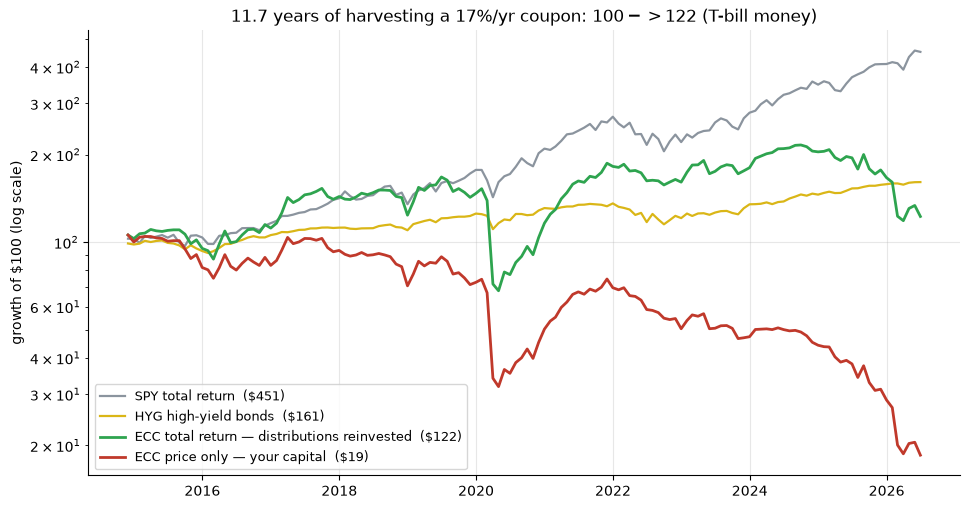

$100 -> ECC TR $122.5 | ECC price-only $18.5 | HYG $160.8 | SPY $450.8


In [2]:
if HAVE_REAL:
    w = {c: (1.0 + MTR[c]).cumprod() * 100 for c in ['ECC','HYG','SPY']}
    w_px = (1.0 + MPX['ECC']).cumprod() * 100
    fig, ax = plt.subplots(figsize=(9.8, 5.2))
    ax.plot(w['SPY'], c=GREY, lw=1.6, label=f"SPY total return  (${w['SPY'].iloc[-1]:.0f})")
    ax.plot(w['HYG'], c=AMBER, lw=1.6, label=f"HYG high-yield bonds  (${w['HYG'].iloc[-1]:.0f})")
    ax.plot(w['ECC'], c=GREEN, lw=2.0, label=f"ECC total return — distributions reinvested  (${w['ECC'].iloc[-1]:.0f})")
    ax.plot(w_px, c=RED, lw=2.0, label=f"ECC price only — your capital  (${w_px.iloc[-1]:.0f})")
    ax.set_yscale('log'); ax.set_ylabel('growth of $100 (log scale)')
    ax.set_title('11.7 years of harvesting a 17%/yr coupon: $100 -> $122 (T-bill money)')
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"$100 -> ECC TR ${w['ECC'].iloc[-1]:.1f} | ECC price-only ${w_px.iloc[-1]:.1f} | "
          f"HYG ${w['HYG'].iloc[-1]:.1f} | SPY ${w['SPY'].iloc[-1]:.1f}")
else:
    print('cache missing - frozen numbers:', '$100 -> ECC TR $%.1f, price-only $%.1f'
          % (R['decomp']['ECC'][6], R['decomp']['ECC'][7]))

The green line is the *best case* — every distribution reinvested, 11.7 years of 17%/yr coupons — and it ends at **$122**, behind the boring high-yield ETF that pays a third of the yield. The red line is your actual capital: **$18** left of $100. On OXLC's longer tape the red line ends at **$9**.

**Now the decomposition per fund.** Green = the distribution stream (real, harvested); red = what the share price did; amber = the total you actually kept.

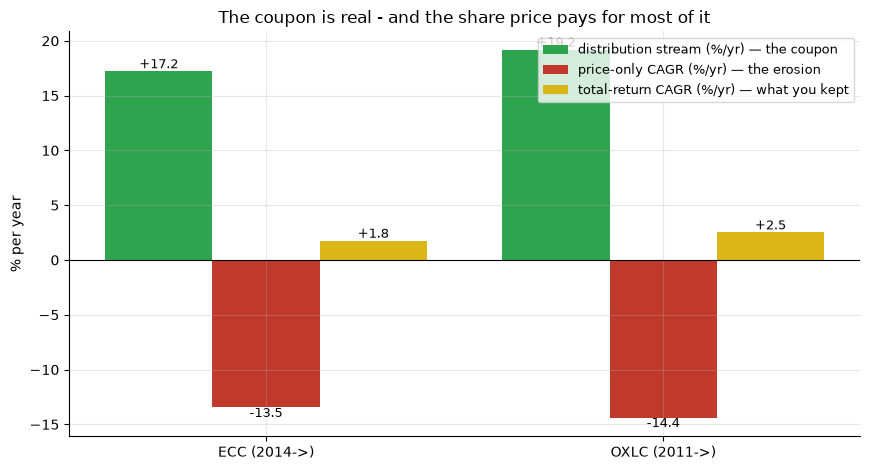

ECC: distribution +17.22%/yr  price -13.46%/yr  total +1.75%/yr
OXLC: distribution +19.19%/yr  price -14.38%/yr  total +2.52%/yr


In [3]:
names = ['ECC', 'OXLC']
if HAVE_REAL:
    rows = []
    for nm in names:
        mtr, mpx = st.aligned_monthly(TR, PX, [nm, 'HYG', 'SPY', 'BIL'])
        dd = st.decompose(mtr, mpx, nm)
        rows.append((dd['dist_ann_pct'], dd['px_cagr_pct'], dd['tr_cagr_pct']))
else:
    rows = [(R['decomp'][nm][2], R['decomp'][nm][5], R['decomp'][nm][4]) for nm in names]
x = np.arange(len(names)); wdt = 0.27
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.bar(x - wdt, [r[0] for r in rows], wdt, color=GREEN, label='distribution stream (%/yr) — the coupon')
ax.bar(x,       [r[1] for r in rows], wdt, color=RED, label='price-only CAGR (%/yr) — the erosion')
ax.bar(x + wdt, [r[2] for r in rows], wdt, color=AMBER, label='total-return CAGR (%/yr) — what you kept')
for i, r in enumerate(rows):
    ax.annotate(f'{r[0]:+.1f}', (i - wdt, r[0]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{r[1]:+.1f}', (i, r[1]), ha='center', va='top', fontsize=9)
    ax.annotate(f'{r[2]:+.1f}', (i + wdt, r[2]), ha='center', va='bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['ECC (2014->)', 'OXLC (2011->)'])
ax.set_ylabel('% per year'); ax.legend(fontsize=9)
ax.set_title('The coupon is real - and the share price pays for most of it')
plt.tight_layout(); plt.show()
for nm, r in zip(names, rows):
    print(f'{nm}: distribution {r[0]:+.2f}%/yr  price {r[1]:+.2f}%/yr  total {r[2]:+.2f}%/yr')

Both funds pay a huge, real coupon (**+17.2%** and **+19.2%** a year) and both funds' *prices* erode at **−13 to −14%/yr**. Do the division: **78%** of ECC's payout and **75%** of OXLC's was offset one-for-one by capital shrinkage. That is the literal definition of being handed your own money back — and the funds' own SEC-mandated 19(a) notices say the same thing in accounting language.

**And the risk while you held it?** Here is the "income sleeve" in the four storms of its life, next to plain high-yield bonds and the stock market:

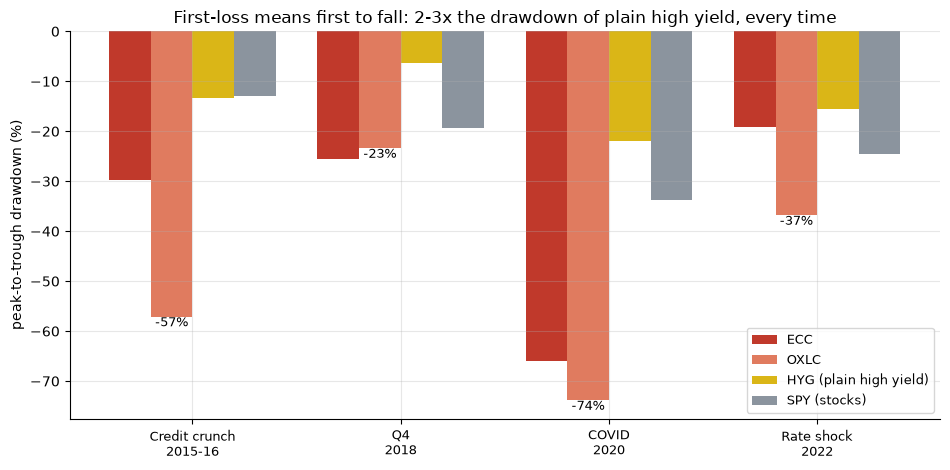

OXLC drawdowns: ['-57.1%', '-23.4%', '-73.8%', '-36.8%']


In [4]:
labels = [c[0] for c in R['crises']]
if HAVE_REAL:
    ct = st.crisis_table(TR, ['ECC', 'OXLC', 'HYG', 'SPY'])
    ecc, oxlc = ct['ECC'].tolist(), ct['OXLC'].tolist()
    hyg, spy = ct['HYG'].tolist(), ct['SPY'].tolist()
else:
    ecc = [c[1] for c in R['crises']]; oxlc = [c[2] for c in R['crises']]
    hyg = [c[3] for c in R['crises']]; spy = [c[4] for c in R['crises']]
x = np.arange(len(labels)); wdt = .2
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.bar(x - 1.5*wdt, ecc, wdt, color=RED, label='ECC')
ax.bar(x - .5*wdt, oxlc, wdt, color='#e07b5f', label='OXLC')
ax.bar(x + .5*wdt, hyg, wdt, color=AMBER, label='HYG (plain high yield)')
ax.bar(x + 1.5*wdt, spy, wdt, color=GREY, label='SPY (stocks)')
for i in range(len(labels)):
    ax.annotate(f'{oxlc[i]:.0f}%', (i - .5*wdt, oxlc[i]), ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([l.replace(' 2', '\n2') for l in labels], fontsize=9)
ax.set_ylabel('peak-to-trough drawdown (%)')
ax.set_title('First-loss means first to fall: 2-3x the drawdown of plain high yield, every time')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print('OXLC drawdowns:', [f'{v:.1f}%' for v in oxlc])

**−66% and −74% in eight weeks** in March 2020, −57% for OXLC in the 2015-16 credit crunch, −37% in 2022 — always a multiple of what plain high-yield bonds did. Why always? Because CLO equity *is* the loss-absorber: it exists so that the AAA buyers above it never lose money. When loan defaults are repriced, the equity tranche's value is the first thing crossed out — and the funds hold it with a second layer of leverage on top.

## 5 · The verdict

- **Signal — Real.** The 15% machine pays — more than advertised: **17.2%** and **19.2%/yr** of hard cash, measured over 11.7 and 15.4 years (statistically bulletproof). The pitch's central number is honest.
- **Tradability — Mirage.** Harvesting that coupon compounded to **T-bill money** (+1.8% and +2.5%/yr) at −60% drawdowns — behind one-click HYG at 3-4× the risk, and 5-8 points a year behind a passive copy of the funds' own risk. The double-digit fee-and-leverage drag inside the wrappers ate the difference.
- **Return OF capital? — Confirmed.** **78%** (ECC) and **75%** (OXLC) of the payout was matched one-for-one by price erosion; $100 of capital → **$18** and **$9**. Spend the distribution and you are eating your principal — with a first-loss credit book attached.

## 6 · Going further 🚪

- **The family pattern.** Bank-loan funds ([340](../../340-bank-loans/README.md)), pipelines ([341](../../341-mlp-pipelines/README.md)), BDCs ([342](../../342-bdc-yield/README.md)), mortgage REITs ([611](../../611-mreit-carry/README.md)), and now CLO equity: package a levered risk premium, label the payout "income," and let the NAV quietly pay for it. When you see a double-digit yield, the first question is never *"is it real?"* — it usually is — but *"what is it liquidating to pay me?"*
- **The tell you can check yourself.** Every closed-end fund must file 19(a) notices saying how much of each distribution is income vs **return of capital**. ECC's and OXLC's have flagged return-of-capital repeatedly. The chart above is just that notice, drawn on the tape.
- **The honest version of the trade.** Institutional CLO *equity held to maturity* has earned real (if dispersed) returns — the Cordell-Roberts-Schwert paper in [docs/references.md](../docs/references.md) is the reference. What retail buys through a 10%+-cost listed wrapper is a different animal.

*Think the post-2022 floating-rate regime changes the answer? The engine is in [`clo_equity_yield/`](../clo_equity_yield/); re-run `examples/verify.py` on any window — the 2020-07+ subperiod is already in the robustness grid, and the price leg still erodes −10 to −13%/yr there.*